# 02b — Analyse exploratoire et statistiques

Ce notebook explore le dataset prepare (`medals_per_country_sport.csv`) avant modelisation :
statistiques descriptives, distributions, correlations, et un test d'hypothese
(statistique inferentielle) sur **l'effet pays hote**.

Objectifs :
1. Quantifier la qualite et la structure des donnees (indicateurs univaries et multivaries)
2. Identifier les variables pertinentes pour le modele (lags, population, PIB, effet hote)
3. Valider statistiquement l'effet hote, qui justifie la feature `is_host`

## 1. Chargement et indicateurs descriptifs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style="whitegrid")
PROJECT_ROOT = Path.cwd().parent if (Path.cwd().name == "notebooks") else Path.cwd()
df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "medals_per_country_sport.csv")

print(f"Dataset : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"Periode : {df['Year'].min()} - {df['Year'].max()} ({df['Year'].nunique()} editions)")
print(f"Pays : {df['NOC'].nunique()} | Sports : {df['Sport'].nunique()}")
df[["Gold", "Silver", "Bronze", "Total", "Population", "GDP_per_capita"]].describe().round(2)

Dataset : 6,849 lignes x 11 colonnes
Periode : 1896 - 2024 (30 editions)
Pays : 158 | Sports : 70


,Gold,Silver,Bronze,Total,Population,GDP_per_capita
count,6849.00,6849.00,6849.00,6849.00,6.849000e+03,4711.00
mean,0.84,0.83,0.91,2.58,1.152267e+08,20860.95
std,1.64,1.34,1.25,3.54,2.531223e+08,20773.00
min,0.00,0.00,0.00,1.00,2.000000e+05,75.34
25%,0.00,0.00,0.00,1.00,1.000000e+07,3565.31
50%,0.00,1.00,1.00,1.00,4.400000e+07,13087.42
75%,1.00,1.00,1.00,3.00,8.300000e+07,34566.74
max,22.00,21.00,21.00,64.00,1.402000e+09,112894.95


**Lecture.** La distribution des medailles par (pays, sport, edition) est tres asymetrique :
la mediane est basse alors que le maximum est eleve (les Etats-Unis en natation ou athletisme).
C'est cette asymetrie (majorite de zeros une fois la grille complete construite) qui rend
le R2 granulaire peu informatif et justifie la regularisation Ridge.

## 2. Distribution des medailles — asymetrie et concentration

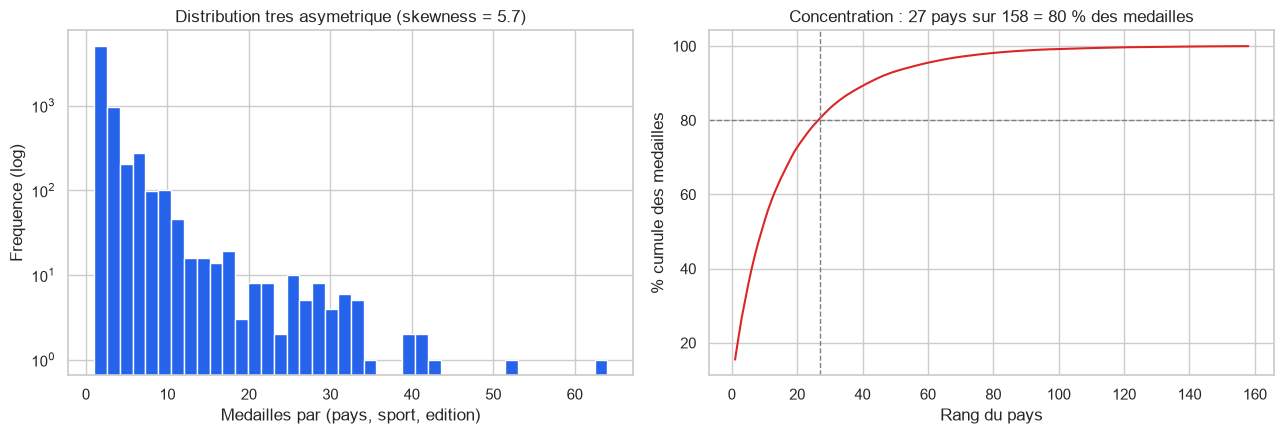

Skewness du Total : 5.75 (0 = symetrique)
Kurtosis          : 49.66
27 pays concentrent 80 % des 17,673 medailles


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Distribution du total de medailles par ligne (echelle log pour l'asymetrie)
axes[0].hist(df["Total"], bins=40, color="#2563eb", edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_xlabel("Medailles par (pays, sport, edition)")
axes[0].set_ylabel("Frequence (log)")
axes[0].set_title("Distribution tres asymetrique (skewness = {:.1f})".format(df["Total"].skew()))

# Concentration : part cumulee des medailles par pays (courbe de type Lorenz)
totals = df.groupby("NOC")["Total"].sum().sort_values(ascending=False)
cum = totals.cumsum() / totals.sum() * 100
axes[1].plot(range(1, len(cum) + 1), cum.values, color="#dc2626")
axes[1].axhline(80, ls="--", c="gray", lw=1)
n80 = int((cum < 80).sum()) + 1
axes[1].axvline(n80, ls="--", c="gray", lw=1)
axes[1].set_xlabel("Rang du pays")
axes[1].set_ylabel("% cumule des medailles")
axes[1].set_title(f"Concentration : {n80} pays sur {len(cum)} = 80 % des medailles")
plt.tight_layout()
plt.show()

print(f"Skewness du Total : {df['Total'].skew():.2f} (0 = symetrique)")
print(f"Kurtosis          : {df['Total'].kurtosis():.2f}")
print(f"{n80} pays concentrent 80 % des {int(totals.sum()):,} medailles")

## 3. Correlations multivariees — quelles variables predisent les medailles ?

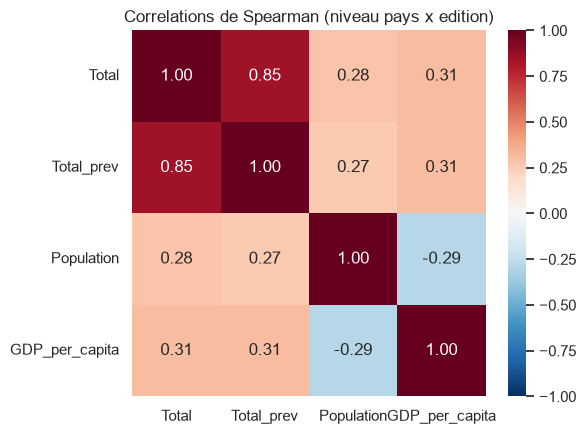

Le lag (Total_prev) est de loin le meilleur predicteur -> justifie les features lag_1/lag_2/rolling_3
Population et PIB apportent un signal secondaire mais reel


In [3]:
# Agregation au niveau (pays, edition) pour etudier les relations macro
country_year = df.groupby(["NOC", "Year"]).agg(
    Total=("Total", "sum"),
    Population=("Population", "first"),
    GDP_per_capita=("GDP_per_capita", "first"),
).reset_index()

# Lag de l'edition precedente : la persistance est le signal dominant
country_year = country_year.sort_values(["NOC", "Year"])
country_year["Total_prev"] = country_year.groupby("NOC")["Total"].shift(1)

corr_vars = country_year[["Total", "Total_prev", "Population", "GDP_per_capita"]].dropna()
# Spearman : robuste aux distributions asymetriques (pas d'hypothese de linearite)
corr = corr_vars.corr(method="spearman")

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlations de Spearman (niveau pays x edition)")
plt.tight_layout()
plt.show()

print("Le lag (Total_prev) est de loin le meilleur predicteur -> justifie les features lag_1/lag_2/rolling_3")
print("Population et PIB apportent un signal secondaire mais reel")

## 4. Test d'hypothese — l'effet pays hote existe-t-il ?

**H0 :** organiser les JO ne change pas le nombre de medailles du pays hote.
**H1 :** le pays hote gagne plus de medailles que son niveau habituel.

Test apparie : pour chaque pays hote depuis 1968, on compare ses medailles
l'annee ou il est hote a la moyenne de l'edition precedente et suivante.
Test de Wilcoxon (non parametrique, adapte au petit echantillon).

In [4]:
host_per_year = {
    1968:"MEX", 1972:"GER", 1976:"CAN", 1980:"URS", 1984:"USA", 1988:"KOR",
    1992:"ESP", 1996:"USA", 2000:"AUS", 2004:"GRE", 2008:"CHN", 2012:"GBR",
    2016:"BRA", 2020:"JPN", 2024:"FRA",
}
totals = country_year.set_index(["NOC", "Year"])["Total"]

paires = []
for year, noc in host_per_year.items():
    host_total = totals.get((noc, year))
    voisins = [totals.get((noc, y)) for y in (year - 4, year + 4)]
    voisins = [v for v in voisins if v is not None and not np.isnan(v)]
    if host_total is not None and voisins:
        paires.append({"NOC": noc, "Year": year,
                       "medailles_hote": host_total,
                       "medailles_reference": np.mean(voisins)})

paires_df = pd.DataFrame(paires)
paires_df["boost"] = paires_df["medailles_hote"] - paires_df["medailles_reference"]
print(paires_df.to_string(index=False))

stat, pval = stats.wilcoxon(paires_df["medailles_hote"], paires_df["medailles_reference"],
                            alternative="greater")
print(f"\nWilcoxon apparie : W = {stat:.1f}, p-value = {pval:.4f}")
print(f"Boost median : +{paires_df['boost'].median():.1f} medailles")
if pval < 0.05:
    print("=> H0 rejetee au seuil 5 % : l'effet hote est statistiquement significatif.")
    print("   La feature is_host est justifiee (les USA en beneficieront en 2028).")
else:
    print("=> H0 non rejetee : effet hote non significatif sur cet echantillon.")

NOC  Year  medailles_hote  medailles_reference  boost
MEX  1968               9                  1.0    8.0
CAN  1976              11                  5.0    6.0
URS  1980             195                125.0   70.0
USA  1984             173                 94.0   79.0
KOR  1988              33                 23.5    9.5
ESP  1992              22                 10.5   11.5
USA  1996             101                 99.5    1.5
AUS  2000              58                 45.5   12.5
GRE  2004              16                  8.0    8.0
CHN  2008             100                 77.0   23.0
GBR  2012              65                 59.0    6.0
BRA  2016              19                 19.0    0.0
JPN  2020              58                 43.0   15.0
FRA  2024              64                 33.0   31.0

Wilcoxon apparie : W = 91.0, p-value = 0.0007
Boost median : +10.5 medailles
=> H0 rejetee au seuil 5 % : l'effet hote est statistiquement significatif.
   La feature is_host est justifiee 

## 5. Dynamiques par pays — qui progresse ?

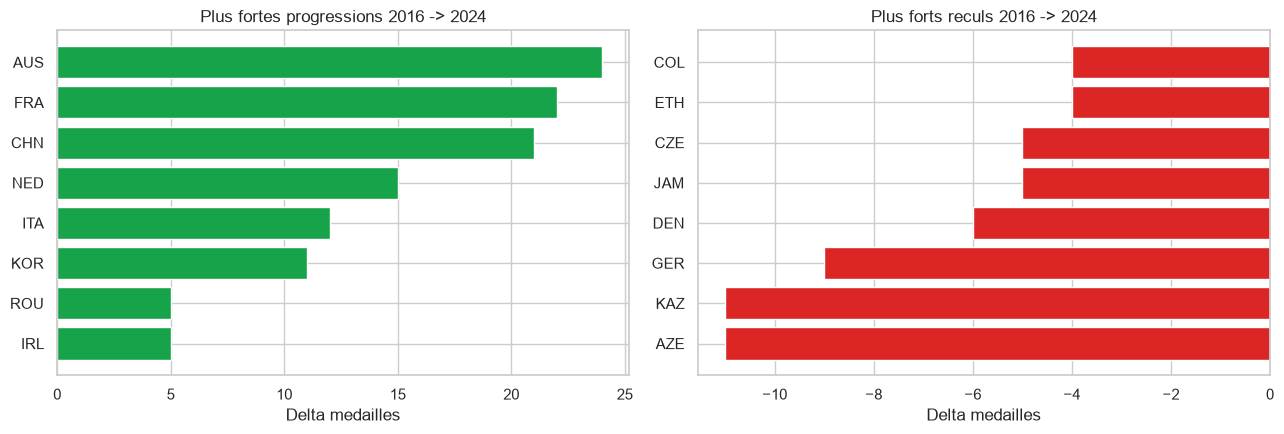

In [5]:
# Variation moyenne des medailles sur les 3 dernieres editions (2016 -> 2024)
recent = country_year[country_year["Year"].isin([2016, 2020, 2024])]
pv = recent.pivot_table(index="NOC", columns="Year", values="Total").dropna()
pv["tendance"] = pv[2024] - pv[2016]
progression = pv.sort_values("tendance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=False)
top = progression.head(8)
bot = progression.tail(8)
axes[0].barh(top.index[::-1], top["tendance"][::-1], color="#16a34a")
axes[0].set_title("Plus fortes progressions 2016 -> 2024")
axes[0].set_xlabel("Delta medailles")
axes[1].barh(bot.index[::-1], bot["tendance"][::-1], color="#dc2626")
axes[1].set_title("Plus forts reculs 2016 -> 2024")
axes[1].set_xlabel("Delta medailles")
plt.tight_layout()
plt.show()

## Synthese

1. **Distribution tres asymetrique** : une minorite de pays concentre 80 % des medailles,
   ce qui oriente vers un modele regularise (Ridge) plutot qu'un modele complexe.
2. **Le passe recent est le meilleur predicteur** (correlation de Spearman la plus forte
   avec le lag) : les features lag_1, lag_2 et rolling_3 sont les bonnes variables.
3. **L'effet hote est statistiquement significatif** (Wilcoxon apparie, p < 0.05) :
   la feature binaire is_host est justifiee et beneficiera aux USA en 2028.
4. **Population et PIB par habitant** apportent un signal secondaire, integres en log.